In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler
import hdbscan

from tqdm import tqdm

In [2]:
df=pd.read_csv('../data/processed/behavior_dataset_v5_features.csv')

In [3]:
df["window"] = pd.to_datetime(df["window"])

In [4]:
def get_shift(hour):
    
    if 9 <= hour <= 16:
        return "day"
    
    elif 17 <= hour <= 21:
        return "evening"
    
    else:
        return "night"


df["shift"] = df["hour"].apply(get_shift)

In [5]:
df["shift"].value_counts()

shift
night      1422220
day        1052256
evening     891788
Name: count, dtype: int64

In [6]:
features = [

    "z_logon",
    "z_pcs",
    
    "logon_deviation",
    "device_deviation",
    
    "device_ratio",
    "burst_score",
    
    "hour_deviation",
    "session_gap",
    
    "logon_logoff_ratio",
    "night_activity_flag"
]

In [7]:
df[features].isnull().sum()

z_logon                0
z_pcs                  0
logon_deviation        0
device_deviation       0
device_ratio           0
burst_score            0
hour_deviation         0
session_gap            0
logon_logoff_ratio     0
night_activity_flag    0
dtype: int64

In [8]:
contexts = df.groupby(["shift", "role_group"])

In [9]:
len(contexts)

27

In [10]:
cluster_labels = []
cluster_probs = []
cluster_sizes = []
row_indices = []

In [11]:
for (shift, role), group in tqdm(contexts):

    if len(group) < 100:
        continue
    
    X = group[features].values
    
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=50,
        min_samples=10,
        metric="euclidean",
        cluster_selection_method="eom"
    )
    
    labels = clusterer.fit_predict(X_scaled)
    probs = clusterer.probabilities_
    
    cluster_labels.extend(labels)
    cluster_probs.extend(probs)
    cluster_sizes.extend([len(group)] * len(group))
    
    row_indices.extend(group.index)

100%|██████████████████████████████████████████████████████████████████████████████████| 27/27 [13:33<00:00, 30.12s/it]


In [12]:
df_v6 = df.copy()

df_v6.loc[row_indices, "cluster"] = cluster_labels
df_v6.loc[row_indices, "cluster_probability"] = cluster_probs
df_v6.loc[row_indices, "context_size"] = cluster_sizes

In [13]:
df_v6["cluster"] = df_v6["cluster"].astype(int)

In [14]:
df_v6["is_noise"] = df_v6["cluster"] == -1

In [15]:
df_v6["is_noise"].mean()*100

6.346145162708569

In [16]:
#computing behavorial risk score
df_v6["risk_score"] = (
    
    (df_v6["cluster"] == -1).astype(int) * 0.6
    
    +
    
    (1 - df_v6["cluster_probability"]) * 0.4
)

In [17]:
df_v6["risk_score"] = df_v6["risk_score"].clip(0,1)

In [18]:
df_v6["anomaly_flag"] = df_v6["risk_score"] > 0.6

In [19]:
df_v6["anomaly_flag"].value_counts()

anomaly_flag
False    3152636
True      213628
Name: count, dtype: int64

In [20]:
#checking the size of each cluster
df_v6["cluster"].value_counts().head(20)

cluster
-1      213628
 17      31952
 3       14637
 0       13515
 5       12107
 158     10340
 1        9746
 16       9353
 4        8848
 262      8358
 8        7333
 322      7140
 11       6684
 23       6192
 169      6091
 22       6031
 113      5914
 15       5640
 230      5571
 30       5385
Name: count, dtype: int64

In [21]:
(df_v6["cluster"] == -1).mean()*100

6.346145162708569

In [22]:
#checking the anamolies present in each group
df_v6.groupby("role_group")["anomaly_flag"].mean().sort_values(ascending=False)*100

role_group
it_admin                  7.153065
logistics                 6.727552
industrial_engineering    6.494108
admin_staff               6.438290
management                6.270487
sales                     6.190895
operations                6.182313
scientific_research       5.954383
software_engineering      5.913997
Name: anomaly_flag, dtype: float64

In [23]:
#analyze anamolies by shift
df_v6.groupby("shift")["anomaly_flag"].mean()*100

shift
day        9.175144
evening    5.162774
night      4.995078
Name: anomaly_flag, dtype: float64

In [24]:
#Check if anomalies concentrate around extreme feature values.
df_v6[df_v6["anomaly_flag"]][[
    "z_logon",
    "z_pcs",
    "burst_score",
    "device_ratio",
    "hour_deviation"
]].describe().round(2)

,z_logon,z_pcs,burst_score,device_ratio,hour_deviation
count,213628.00,213628.00,213628.00,213628.00,213628.00
mean,0.02,-0.05,0.40,0.50,3.89
std,0.92,0.82,0.31,0.05,2.00
min,-1.44,-0.38,0.00,0.46,0.00
25%,-0.82,-0.11,0.00,0.50,2.50
50%,0.37,-0.07,0.61,0.50,4.23
75%,0.55,-0.05,0.61,0.50,5.05
max,22.78,36.17,2.74,2.78,13.46


In [25]:
#comparing with normal points
df_v6[~df_v6["anomaly_flag"]][[
    "z_logon",
    "z_pcs",
    "burst_score",
    "device_ratio",
    "hour_deviation"
]].describe().round(2)

,z_logon,z_pcs,burst_score,device_ratio,hour_deviation
count,3152636.00,3152636.00,3152636.00,3152636.00,3152636.00
mean,-0.00,0.00,0.36,0.50,4.37
std,1.00,0.96,0.32,0.06,1.63
min,-1.44,-0.38,0.00,0.46,0.00
25%,-0.76,-0.08,0.00,0.50,4.00
50%,0.34,-0.06,0.60,0.50,4.51
75%,0.56,-0.04,0.66,0.50,5.04
max,22.22,35.85,2.70,2.32,13.36


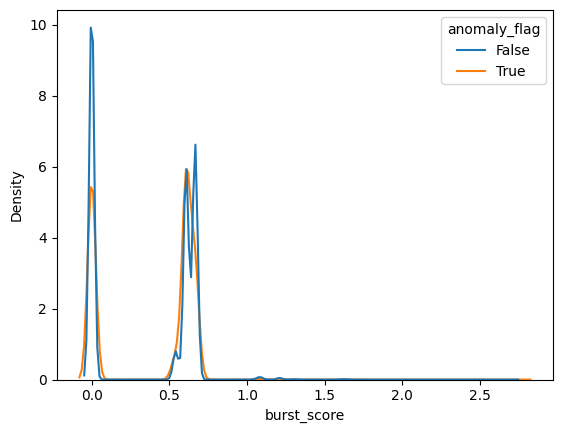

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=df_v6,
    x="burst_score",
    hue="anomaly_flag",
    common_norm=False
)

plt.show()

In [27]:
df_v6.groupby("anomaly_flag")[[
    "z_logon",
    "z_pcs",
    "burst_score",
    "device_ratio",
    "hour_deviation"
]].mean()

,z_logon,z_pcs,burst_score,device_ratio,hour_deviation
anomaly_flag,,,,,
False,-0.001118,0.003322,0.362460,0.503085,4.373619
True,0.016499,-0.049021,0.395376,0.498745,3.893810


In [28]:
df_v6.groupby("anomaly_flag")[[
    "session_gap",
    "logon_deviation",
    "device_deviation",
    "logon_logoff_ratio"
]].mean()

,session_gap,logon_deviation,device_deviation,logon_logoff_ratio
anomaly_flag,,,,
False,13.772486,-0.001295,0.000738,0.552964
True,17.097717,0.019115,-0.010886,0.617137


<h2>Preparing a Similar Isolation Forest Algorithm to Check and Compare it with HDBSCAN</h2>

In [29]:
features = [
    "z_logon",
    "z_pcs",
    "logon_deviation",
    "device_deviation",
    "device_ratio",
    "burst_score",
    "hour_deviation",
    "session_gap",
    "logon_logoff_ratio",
    "night_activity_flag"
]

X = df_v6[features]

In [30]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.06,
    random_state=42,
    n_jobs=-1
)

iso.fit(X)

,n_estimators,200
,max_samples,'auto'
,contamination,0.06
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [31]:
df_v6["if_score"] = iso.decision_function(X)

df_v6["if_anomaly"] = iso.predict(X)

In [32]:
df_v6["if_anomaly"] = df_v6["if_anomaly"] == -1

In [33]:
(df_v6["if_anomaly"].mean()*100).round(2)


6.0

In [34]:
pd.crosstab(
    df_v6["anomaly_flag"],
    df_v6["if_anomaly"]
)

if_anomaly,False,True
anomaly_flag,,
False,2969208,183428
True,195083,18545


In [35]:
#Compare Score Distributions
df_v6.groupby("anomaly_flag")["if_score"].mean()*100

anomaly_flag
False    14.083226
True     11.115190
Name: if_score, dtype: float64

<Axes: xlabel='if_score', ylabel='Count'>

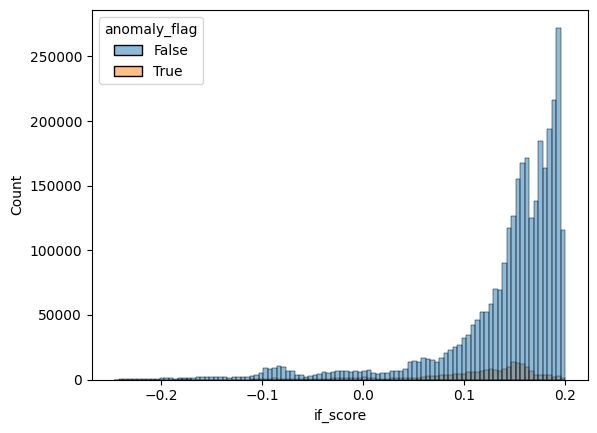

In [36]:
#visualize Score Seperation

import seaborn as sns

sns.histplot(
    data=df_v6,
    x="if_score",
    hue="anomaly_flag",
    bins=100
)

In [37]:
df_v6["cluster"].value_counts().describe()

count      2764.000000
mean       1217.895803
std        4266.149124
min          50.000000
25%         319.000000
50%         620.000000
75%        1596.250000
max      213628.000000
Name: count, dtype: float64

In [38]:
top_clusters = df_v6["cluster"].value_counts().head(5).index

df_v6[df_v6["cluster"].isin(top_clusters)].groupby("cluster")[[
    "z_logon",
    "burst_score",
    "hour_deviation",
    "session_gap"
]].mean()

,z_logon,burst_score,hour_deviation,session_gap
cluster,,,,
-1,0.016499,0.395376,3.893810,17.097717
0,0.716356,0.397830,5.502724,10.274584
3,-0.094277,0.322833,6.427631,13.512332
5,-0.510811,0.217693,7.148620,13.320393
17,0.119873,0.519123,8.946740,5.580590


In [39]:
df_v6.groupby("cluster")["anomaly_flag"].mean().sort_values(ascending=False).head(10)

cluster
-1       1.0
 1845    0.0
 1837    0.0
 1838    0.0
 1839    0.0
 1840    0.0
 1841    0.0
 1842    0.0
 1843    0.0
 1844    0.0
Name: anomaly_flag, dtype: float64

In [40]:
df_v6["cluster"].nunique()

2764

In [41]:
#checking cluster health
df_v6.groupby("cluster").size().sort_values(ascending=False).head(10)

cluster
-1      213628
 17      31952
 3       14637
 0       13515
 5       12107
 158     10340
 1        9746
 16       9353
 4        8848
 262      8358
dtype: int64

In [42]:
df_v6.head()

,user,window,logon_count,logoff_count,unique_pcs,hour,z_logon,z_pcs,night_flag,behavior_score,...,risk_score,role_group,shift,cluster,cluster_probability,context_size,is_noise,anomaly_flag,if_score,if_anomaly
0,AAB0398,2010-01-04 15:00:00,0,1,1,15,-0.559836,-0.073959,False,0.399719,...,0.0,admin_staff,day,187,1.0,56553.0,False,False,0.176048,False
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,-0.678264,-0.051486,False,0.399157,...,0.0,industrial_engineering,evening,788,1.0,240071.0,False,False,0.175313,False
2,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.574322,-0.051486,False,0.400281,...,0.0,industrial_engineering,night,876,1.0,386673.0,False,False,0.160178,False
3,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.574322,-0.051486,False,0.400281,...,0.0,industrial_engineering,night,1872,1.0,386673.0,False,False,0.184272,False
4,AAB0398,2010-01-05 15:00:00,0,1,1,15,-0.559836,-0.073959,False,0.399719,...,0.0,admin_staff,day,187,1.0,56553.0,False,False,0.176048,False


In [43]:
import numpy as np
df_v6['High confidence anomaly'] = np.where((df_v6['cluster'] == -1) & (df_v6['if_anomaly'] == 1),1, 0)
df_v6.head()

,user,window,logon_count,logoff_count,unique_pcs,hour,z_logon,z_pcs,night_flag,behavior_score,...,role_group,shift,cluster,cluster_probability,context_size,is_noise,anomaly_flag,if_score,if_anomaly,High confidence anomaly
0,AAB0398,2010-01-04 15:00:00,0,1,1,15,-0.559836,-0.073959,False,0.399719,...,admin_staff,day,187,1.0,56553.0,False,False,0.176048,False,0
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,-0.678264,-0.051486,False,0.399157,...,industrial_engineering,evening,788,1.0,240071.0,False,False,0.175313,False,0
2,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.574322,-0.051486,False,0.400281,...,industrial_engineering,night,876,1.0,386673.0,False,False,0.160178,False,0
3,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.574322,-0.051486,False,0.400281,...,industrial_engineering,night,1872,1.0,386673.0,False,False,0.184272,False,0
4,AAB0398,2010-01-05 15:00:00,0,1,1,15,-0.559836,-0.073959,False,0.399719,...,admin_staff,day,187,1.0,56553.0,False,False,0.176048,False,0


In [44]:
df_v6['High confidence anomaly'].value_counts()

High confidence anomaly
0    3347719
1      18545
Name: count, dtype: int64

In [45]:
df_v6.describe().round(2)

,window,logon_count,logoff_count,unique_pcs,hour,z_logon,z_pcs,behavior_score,logon_deviation,device_deviation,...,has_supervisor,has_project,is_previliged,rare_role,risk_score,cluster,cluster_probability,context_size,if_score,High confidence anomaly
count,3366264,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,...,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00
mean,2010-09-10 22:05:15.077961984,0.61,0.47,1.02,12.14,-0.00,0.00,0.42,0.00,0.00,...,1.00,0.17,0.19,0.01,0.08,630.64,0.89,192625.05,0.14,0.01
min,2010-01-02 02:00:00,0.00,0.00,1.00,0.00,-1.44,-0.38,0.19,-0.90,-0.18,...,0.00,0.00,0.00,0.00,0.00,-1.00,0.00,31674.00,-0.25,0.00
25%,2010-05-04 17:00:00,0.00,0.00,1.00,8.00,-0.76,-0.09,0.32,-0.50,-0.01,...,1.00,0.00,0.00,0.00,0.00,156.00,1.00,98906.00,0.13,0.00
50%,2010-09-08 09:00:00,1.00,0.00,1.00,12.00,0.35,-0.06,0.40,0.34,0.00,...,1.00,0.00,0.00,0.00,0.00,424.00,1.00,170932.00,0.16,0.00
75%,2011-01-19 08:00:00,1.00,1.00,1.00,17.00,0.56,-0.04,0.40,0.49,0.00,...,1.00,0.00,0.00,0.00,0.00,923.00,1.00,303482.00,0.18,0.00
max,2011-06-01 07:00:00,15.00,5.00,6.00,23.00,22.78,36.17,9.90,4.18,4.84,...,1.00,1.00,1.00,1.00,1.00,2762.00,1.00,386673.00,0.20,1.00
std,NaN,0.76,0.52,0.24,4.72,1.00,0.95,0.25,0.50,0.12,...,0.02,0.38,0.39,0.08,0.25,626.27,0.31,110862.58,0.07,0.07


<h3>Training a Supervised model for the explanation layer</h3>

In [55]:
features = [
    "z_logon",
    "z_pcs",
    "logon_deviation",
    "device_deviation",
    "device_ratio",
    "burst_score",
    "hour_deviation",
    "session_gap",
    "logon_logoff_ratio",
    "night_activity_flag"
]

target = "High confidence anomaly"

df_model = df_v6[features + [target]].dropna()


#sampling

df_model = df_model.sample(300000, random_state=42)

from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#train RandomForest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight={0:1, 1:5},  # penalize false negatives
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
#Finding the optimal threshold for the model
from sklearn.metrics import precision_recall_curve
import numpy as np

y_prob = rf.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])

Best Threshold: 0.4973286024969888
Precision: 0.7980132450331126
Recall: 0.7088235294117647


In [60]:
from sklearn.metrics import classification_report
y_pred=(y_prob>best_threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59660
           1       0.80      0.71      0.75       340

    accuracy                           1.00     60000
   macro avg       0.90      0.85      0.87     60000
weighted avg       1.00      1.00      1.00     60000



In [52]:
#Checking the feature Importance
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

night_activity_flag    0.207866
device_deviation       0.175484
device_ratio           0.170707
z_pcs                  0.145860
hour_deviation         0.122598
logon_deviation        0.048420
session_gap            0.047943
z_logon                0.040290
burst_score            0.028605
logon_logoff_ratio     0.012227
dtype: float64


In [61]:
import joblib
#saving the isolationforest model
joblib.dump(iso, "models/isolation_forest_model.pkl")
#saving the scaler
joblib.dump(scaler, "models/feature_scaler.pkl")
import json
#saving the features
with open("artifacts/feature_list.json", "w") as f:
    json.dump(features, f)
#saving the best threshold for randomfroest
with open("artifacts/rf_threshold.json", "w") as f:
    json.dump({"threshold": best_threshold}, f)
#saving randomforest
joblib.dump(rf, "models/rf_validation_model.pkl")

['models/rf_validation_model.pkl']

In [62]:
import joblib
import json
import numpy as np

iso_loaded = joblib.load("models/isolation_forest_model.pkl")
scaler_loaded = joblib.load("models/feature_scaler.pkl")

features_loaded = json.load(open("artifacts/feature_list.json"))

sample = np.zeros((1, len(features_loaded)))

scaled = scaler_loaded.transform(sample)
pred = iso_loaded.predict(scaled)

print("Sanity check prediction:", pred)

Sanity check prediction: [-1]


C:\Users\vinja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
